In [1]:
import numpy as np
import pandas as pd

 - Data integration is the process of combining, cleaning, and consolidating data from disparate sources—such as databases, SaaS applications, and APIs—into a single, coherent view. By eliminating data silos, this process provides accurate, up-to-date information for analysis, AI-driven insights, and improved business decision-making.

 - Key Components and Techniques
 - ETL (Extract, Transform, Load): Data is extracted, cleaned, and transformed before being loaded into a warehouse.
 - ELT (Extract, Load, Transform): Data is loaded immediately and transformed within the target system (e.g., data lakehouse), faster for large volumes.
 - Data Virtualization: Creates a virtual, unified view without physically moving the data.Streaming Data 
 - Integration: Processes real-time data for immediate insights.API Integration: Uses application programming interfaces to connect systems.

## Concatenation

In [2]:
# df1 = pd.DataFrame(
#     {
#         'accountno':[123, 674, 345, 109],
#         'name':['John', 'Aston', 'Saimon', 'Kevin'],
#         'age': [23, 41, 31, 65]
#     }
# )
# df2 = pd.DataFrame(
#     {
#         'accountno':[123, 674, 345, 109],
#         'saving':[1300, 450, 670, 9001],
#         'interest': [4.2, 4.1, 3.4, 6.5]
#     }
# )

In [3]:
# pd.concat([df1, df2], axis=0, ignore_index=True)

In [4]:
# pd.concat([df1, df2], axis=1)

## Merging
pd.merge() is a powerful Pandas function designed to combine two DataFrames based on a common key, column, or index, functioning similarly to SQL-style joins. It offers high versatility for integrating data from multiple sources.

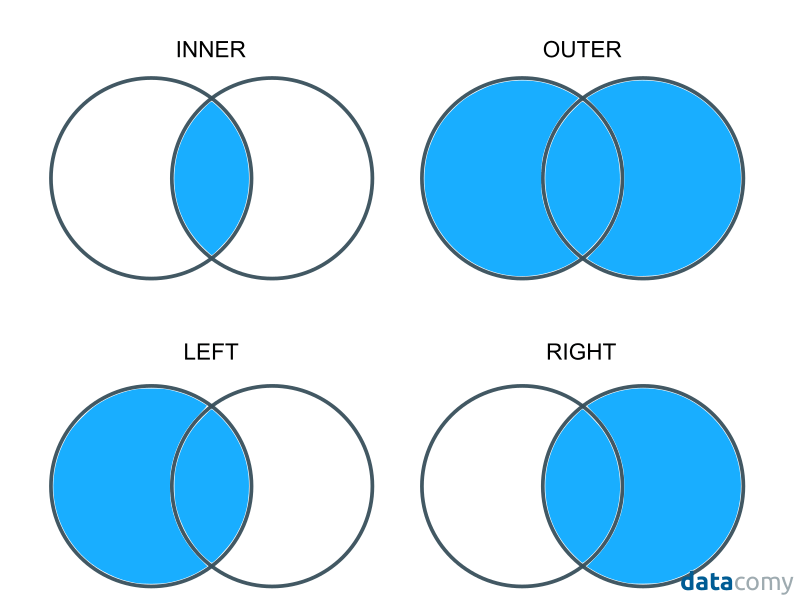

In [5]:
df1 = pd.DataFrame(
    {
        'accountno':[123, 674, 345, 109, 300],
        'name':['John', 'Aston', 'Saimon', 'Bob', 'Kevin'],
        'age': [23, 41, 31, 65, 34]
    }
)
df2 = pd.DataFrame(
    {
        'accountno':[123, 674, 345, 109, 200],
        'saving':[1300, 450, 670, 9001, 470],
        'interest': [4.2, 4.1, 3.4, 6.5, 5.4],
        'age': [23, 41, 31, 65, 34]
    }
)

In [6]:
df1

,accountno,name,age
0,123,John,23
1,674,Aston,41
2,345,Saimon,31
3,109,Bob,65
4,300,Kevin,34


In [7]:
df2

,accountno,saving,interest,age
0,123,1300,4.2,23
1,674,450,4.1,41
2,345,670,3.4,31
3,109,9001,6.5,65
4,200,470,5.4,34


In [8]:
pd.merge(df1, df2, how = 'inner', on = 'accountno', suffixes=('_df1', '_df2'))

,accountno,name,age_df1,saving,interest,age_df2
0,123,John,23,1300,4.2,23
1,674,Aston,41,450,4.1,41
2,345,Saimon,31,670,3.4,31
3,109,Bob,65,9001,6.5,65


In [9]:
pd.merge(df1, df2, how = 'outer', on = 'accountno', indicator=True)

,accountno,name,age_x,saving,interest,age_y,_merge
0,109,Bob,65.0,9001.0,6.5,65.0,both
1,123,John,23.0,1300.0,4.2,23.0,both
2,200,NaN,NaN,470.0,5.4,34.0,right_only
3,300,Kevin,34.0,NaN,NaN,NaN,left_only
4,345,Saimon,31.0,670.0,3.4,31.0,both
5,674,Aston,41.0,450.0,4.1,41.0,both


In [10]:
pd.merge(df1, df2, how = 'left', on = 'accountno')

,accountno,name,age_x,saving,interest,age_y
0,123,John,23,1300.0,4.2,23.0
1,674,Aston,41,450.0,4.1,41.0
2,345,Saimon,31,670.0,3.4,31.0
3,109,Bob,65,9001.0,6.5,65.0
4,300,Kevin,34,NaN,NaN,NaN


In [11]:
pd.merge(df1, df2, how = 'right', on = 'accountno')

,accountno,name,age_x,saving,interest,age_y
0,123,John,23.0,1300,4.2,23
1,674,Aston,41.0,450,4.1,41
2,345,Saimon,31.0,670,3.4,31
3,109,Bob,65.0,9001,6.5,65
4,200,NaN,NaN,470,5.4,34


In [12]:
# Alternative
df1.merge(df2, on = 'accountno', how = 'inner')

,accountno,name,age_x,saving,interest,age_y
0,123,John,23,1300,4.2,23
1,674,Aston,41,450,4.1,41
2,345,Saimon,31,670,3.4,31
3,109,Bob,65,9001,6.5,65


## Joining

In [13]:
df1_i = df1.set_index('accountno')
df1_i

,name,age
accountno,,
123,John,23
674,Aston,41
345,Saimon,31
109,Bob,65
300,Kevin,34


In [14]:
df2_i = df2.set_index('accountno')
df2_i

,saving,interest,age
accountno,,,
123,1300,4.2,23
674,450,4.1,41
345,670,3.4,31
109,9001,6.5,65
200,470,5.4,34


In [15]:
df1_i.join(df2_i, how = 'inner', lsuffix='left', rsuffix='right')

,name,ageleft,saving,interest,ageright
accountno,,,,,
123,John,23,1300,4.2,23
674,Aston,41,450,4.1,41
345,Saimon,31,670,3.4,31
109,Bob,65,9001,6.5,65


In [16]:
df1_i.join(df2_i, how = 'left', lsuffix='left', rsuffix='right')

,name,ageleft,saving,interest,ageright
accountno,,,,,
123,John,23,1300.0,4.2,23.0
674,Aston,41,450.0,4.1,41.0
345,Saimon,31,670.0,3.4,31.0
109,Bob,65,9001.0,6.5,65.0
300,Kevin,34,NaN,NaN,NaN


In [17]:
df1_i.join(df2_i, how = 'outer', lsuffix='left', rsuffix='right')

,name,ageleft,saving,interest,ageright
accountno,,,,,
109,Bob,65.0,9001.0,6.5,65.0
123,John,23.0,1300.0,4.2,23.0
200,NaN,NaN,470.0,5.4,34.0
300,Kevin,34.0,NaN,NaN,NaN
345,Saimon,31.0,670.0,3.4,31.0
674,Aston,41.0,450.0,4.1,41.0


In [18]:
df1_i.join(df2_i, how = 'right', lsuffix='left', rsuffix='right')

,name,ageleft,saving,interest,ageright
accountno,,,,,
123,John,23.0,1300,4.2,23
674,Aston,41.0,450,4.1,41
345,Saimon,31.0,670,3.4,31
109,Bob,65.0,9001,6.5,65
200,NaN,NaN,470,5.4,34


## Stacking
.stack() in pandas is used to reshape a DataFrame by converting columns into rows.

It “stacks” the column labels downward into the index.

In [19]:
df1

,accountno,name,age
0,123,John,23
1,674,Aston,41
2,345,Saimon,31
3,109,Bob,65
4,300,Kevin,34


In [20]:
stacked = df1.stack()
stacked

0  accountno       123
   name           John
   age              23
1  accountno       674
   name          Aston
   age              41
2  accountno       345
   name         Saimon
   age              31
3  accountno       109
   name            Bob
   age              65
4  accountno       300
   name          Kevin
   age              34
dtype: object